# Breast Cancer Gene Expression Analysis

## Project Objective

The goal of this project is to analyze publicly available human gene expression data and compare breast cancer tissue with normal breast tissue.

Dataset: NCBI Gene Expression Omnibus (GEO)
Accession: GSE15852

The dataset contains gene expression measurements from 43 breast tumor samples and 43 paired normal breast tissue samples.

The main objective is to identify genes that show differences in expression between tumor and normal tissue and visualize these differences using Python.

## 1. Import Libraries

Python libraries used in this analysis:
- Pandas for data manipulation and analysis
- NumPy for numerical operations
- Matplotlib for data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Gene Expression Dataset

Gene expression data were obtained from the NCBI Gene Expression Omnibus (GEO), accession GSE15852.

This study contains paired breast tumor and normal breast tissue samples analyzed using the Affymetrix Human Genome U133A microarray platform.

In [2]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15852/matrix/GSE15852_series_matrix.txt.gz"

geo_data = pd.read_csv(
    url,
    sep="\t",
    comment="!",
    compression="gzip",
    index_col=0
)

print("Dataset loaded successfully!")
print("Dataset shape:", geo_data.shape)

Dataset loaded successfully!
Dataset shape: (22283, 86)


## 3. Explore the Dataset

Before performing the analysis, the dataset was inspected to understand its dimensions, sample identifiers, probe identifiers, and expression values.

In [3]:
print("Number of probe sets:", geo_data.shape[0])
print("Number of samples:", geo_data.shape[1])

geo_data.head()

Number of probe sets: 22283
Number of samples: 86


,GSM398074,GSM398075,GSM398076,GSM398077,GSM398078,GSM398079,GSM398080,GSM398081,GSM398082,GSM398083,...,GSM398150,GSM398151,GSM398152,GSM398153,GSM398154,GSM398155,GSM398156,GSM398157,GSM398158,GSM398159
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,1881.8000,2317.510,1553.8600,1915.5700,1240.130,2448.110,1007.430,1827.9500,956.965,1973.0500,...,1434.710,5158.850,1753.98,2876.290,1955.950,2993.6100,1467.170,5501.4100,2387.610,4809.980
1053_at,78.0658,61.354,80.0525,79.8518,104.933,78.429,152.432,72.7092,134.470,48.4393,...,144.179,134.313,168.42,117.656,126.613,68.1142,104.309,69.8169,113.436,189.753
117_at,1299.9800,775.547,1103.7400,762.0050,820.822,674.293,917.559,785.6660,822.412,894.3730,...,1158.640,939.759,1691.42,1617.200,1985.690,2026.0600,1583.960,1603.2700,2224.050,1357.030
121_at,3086.7200,2335.150,3139.6500,2338.4800,2555.460,2181.160,2235.280,2293.7400,2354.170,2453.1400,...,4040.670,3088.210,3212.16,3953.610,4892.410,5061.0300,3814.230,4844.5200,5158.760,4454.040
1255_g_at,353.8900,303.653,523.8730,222.5520,401.749,387.795,661.785,280.1050,212.896,195.9050,...,608.045,683.685,866.32,504.712,732.156,1092.1500,704.721,1007.8000,698.488,836.205


## 4. Identify Sample Groups

The expression matrix contains 86 samples identified by GEO accession numbers (GSM IDs). Sample metadata are used to determine which samples represent breast tumor tissue and which represent paired normal breast tissue.

In [4]:
print("First 10 sample IDs:")
print(geo_data.columns[:10])

print("\nLast 10 sample IDs:")
print(geo_data.columns[-10:])

First 10 sample IDs:
Index(['GSM398074', 'GSM398075', 'GSM398076', 'GSM398077', 'GSM398078',
       'GSM398079', 'GSM398080', 'GSM398081', 'GSM398082', 'GSM398083'],
      dtype='object')

Last 10 sample IDs:
Index(['GSM398150', 'GSM398151', 'GSM398152', 'GSM398153', 'GSM398154',
       'GSM398155', 'GSM398156', 'GSM398157', 'GSM398158', 'GSM398159'],
      dtype='object')


In [5]:
normal_samples = geo_data.columns[0::2]
tumor_samples = geo_data.columns[1::2]

print("Number of normal samples:", len(normal_samples))
print("Number of tumor samples:", len(tumor_samples))

print("\nFirst 5 normal samples:")
print(normal_samples[:5])

print("\nFirst 5 tumor samples:")
print(tumor_samples[:5])

Number of normal samples: 43
Number of tumor samples: 43

First 5 normal samples:
Index(['GSM398074', 'GSM398076', 'GSM398078', 'GSM398080', 'GSM398082'], dtype='object')

First 5 tumor samples:
Index(['GSM398075', 'GSM398077', 'GSM398079', 'GSM398081', 'GSM398083'], dtype='object')


## 5. Compare Average Expression Between Normal and Tumor Samples

For each probe set, the mean expression level was calculated separately across the 43 normal breast tissue samples and the 43 breast tumor samples. This provides an initial comparison of gene expression between the two groups.

In [6]:
geo_data["Normal_Mean"] = geo_data[normal_samples].mean(axis=1)
geo_data["Tumor_Mean"] = geo_data[tumor_samples].mean(axis=1)

geo_data[["Normal_Mean", "Tumor_Mean"]].head()

,Normal_Mean,Tumor_Mean
ID_REF,,
1007_s_at,1641.371605,2663.963837
1053_at,106.374235,89.832300
117_at,1230.850651,990.130581
121_at,3162.623488,2951.051628
1255_g_at,429.972930,433.604721


## 6. Calculate Fold Change

To measure differences in expression between tumor and normal tissue, log2 fold change was calculated for each probe set.

A positive log2 fold change indicates higher expression in tumor tissue, while a negative value indicates lower expression in tumor tissue.

In [7]:
geo_data["Log2_Fold_Change"] = np.log2(
    (geo_data["Tumor_Mean"] + 1) /
    (geo_data["Normal_Mean"] + 1)
)

geo_data[
    ["Normal_Mean", "Tumor_Mean", "Log2_Fold_Change"]
].head()

,Normal_Mean,Tumor_Mean,Log2_Fold_Change
ID_REF,,,
1007_s_at,1641.371605,2663.963837,0.698335
1053_at,106.374235,89.832300,-0.241371
117_at,1230.850651,990.130581,-0.313680
121_at,3162.623488,2951.051628,-0.099860
1255_g_at,429.972930,433.604721,0.012107


## 7. Identify Probe Sets With the Largest Expression Changes

Probe sets were ranked by log2 fold change to identify those showing the largest increases or decreases in expression between breast tumor and normal tissue.

In [8]:
top_upregulated = geo_data.sort_values(
    "Log2_Fold_Change",
    ascending=False
)

print("Top 10 probe sets with higher expression in tumor:")

top_upregulated[
    ["Normal_Mean", "Tumor_Mean", "Log2_Fold_Change"]
].head(10)

Top 10 probe sets with higher expression in tumor:


,Normal_Mean,Tumor_Mean,Log2_Fold_Change
ID_REF,,,
201650_at,291.798188,2541.332223,3.118174
209016_s_at,70.498470,617.412305,3.112585
37892_at,130.213505,1112.790779,3.085490
266_s_at,402.481812,2773.110430,2.781450
208650_s_at,168.074865,949.126902,2.490458
213693_s_at,162.963326,904.538428,2.465403
212281_s_at,110.734421,589.362886,2.401528
205916_at,76.318488,399.751777,2.373824
201596_x_at,342.674912,1757.605574,2.355316


In [9]:
top_downregulated = geo_data.sort_values(
    "Log2_Fold_Change",
    ascending=True
)

print("Top 10 probe sets with lower expression in tumor:")

top_downregulated[
    ["Normal_Mean", "Tumor_Mean", "Log2_Fold_Change"]
].head(10)

Top 10 probe sets with lower expression in tumor:


,Normal_Mean,Tumor_Mean,Log2_Fold_Change
ID_REF,,,
222317_at,774.444488,57.859923,-3.719666
219140_s_at,3211.885688,301.282305,-3.409901
205478_at,1398.224319,149.878907,-3.213164
204997_at,963.756463,129.146684,-2.890026
206243_at,985.585884,133.320844,-2.876761
207092_at,2855.510888,415.974167,-2.776224
213071_at,2034.338907,317.376602,-2.676463
211745_x_at,5210.885628,836.981721,-2.636815
205382_s_at,4895.111849,802.848188,-2.606642


## 8. Statistical Testing

Because the dataset contains paired tumor and normal tissue samples from the same patients, a paired statistical test was used to evaluate expression differences for each probe set.

A paired t-test was performed for each probe set to determine whether the difference between tumor and normal expression was statistically significant.

In [10]:
from scipy.stats import ttest_rel

print("SciPy loaded successfully!")

SciPy loaded successfully!


In [11]:
p_values = []

for probe in geo_data.index:
    normal_values = geo_data.loc[probe, normal_samples].astype(float)
    tumor_values = geo_data.loc[probe, tumor_samples].astype(float)

    t_stat, p_value = ttest_rel(tumor_values, normal_values)

    p_values.append(p_value)

geo_data["P_Value"] = p_values

print("Statistical testing completed!")

geo_data[
    ["Normal_Mean", "Tumor_Mean", "Log2_Fold_Change", "P_Value"]
].head()

Statistical testing completed!


,Normal_Mean,Tumor_Mean,Log2_Fold_Change,P_Value
ID_REF,,,,
1007_s_at,1641.371605,2663.963837,0.698335,3.165707e-08
1053_at,106.374235,89.832300,-0.241371,1.090603e-01
117_at,1230.850651,990.130581,-0.313680,4.317009e-05
121_at,3162.623488,2951.051628,-0.099860,6.778975e-02
1255_g_at,429.972930,433.604721,0.012107,8.945912e-01


## 9. Multiple Testing Correction

Because thousands of probe sets were tested simultaneously, raw p-values were adjusted for multiple comparisons using the Benjamini-Hochberg false discovery rate (FDR) method.

This reduces the number of false-positive findings that can occur when performing thousands of statistical tests.

In [12]:
from statsmodels.stats.multitest import multipletests

_, adjusted_p_values, _, _ = multipletests(
    geo_data["P_Value"],
    method="fdr_bh"
)

geo_data["Adjusted_P_Value"] = adjusted_p_values

print("FDR correction completed!")

geo_data[
    ["Log2_Fold_Change", "P_Value", "Adjusted_P_Value"]
].head()

FDR correction completed!


,Log2_Fold_Change,P_Value,Adjusted_P_Value
ID_REF,,,
1007_s_at,0.698335,3.165707e-08,0.000003
1053_at,-0.241371,1.090603e-01,0.255600
117_at,-0.313680,4.317009e-05,0.001000
121_at,-0.099860,6.778975e-02,0.188979
1255_g_at,0.012107,8.945912e-01,0.942559


## 10. Identify Differentially Expressed Probe Sets

Probe sets were considered candidate differentially expressed if they met both of the following criteria:

- Adjusted p-value (FDR) < 0.05
- Absolute log2 fold change ≥ 1

These thresholds identify probe sets showing both statistical evidence of differential expression and a substantial difference in expression magnitude between tumor and normal tissue.

In [13]:
significant_probes = geo_data[
    (geo_data["Adjusted_P_Value"] < 0.05) &
    (abs(geo_data["Log2_Fold_Change"]) >= 1)
]

print("Total probe sets:", len(geo_data))
print("Significant differentially expressed probe sets:", len(significant_probes))

Total probe sets: 22283
Significant differentially expressed probe sets: 443


In [14]:
upregulated_probes = significant_probes[
    significant_probes["Log2_Fold_Change"] >= 1
]

downregulated_probes = significant_probes[
    significant_probes["Log2_Fold_Change"] <= -1
]

print("Higher in tumor:", len(upregulated_probes))
print("Lower in tumor:", len(downregulated_probes))

Higher in tumor: 181
Lower in tumor: 262


## 11. Map Probe Sets to Gene Symbols

The expression dataset uses Affymetrix probe-set identifiers rather than gene symbols. Platform annotation from the GPL96 Affymetrix Human Genome U133A Array was used to map probe-set IDs to their corresponding gene symbols.

In [15]:
import requests

probe_ids = significant_probes.index.tolist()

print("Number of probe IDs to map:", len(probe_ids))
print("First 5 probe IDs:", probe_ids[:5])

Number of probe IDs to map: 443
First 5 probe IDs: ['200750_s_at', '200770_s_at', '200844_s_at', '200878_at', '200895_s_at']


In [17]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL96&targ=self&form=text&view=data"

response = requests.get(url)
text = response.text

start = text.find("!platform_table_begin")
end = text.find("!platform_table_end")

table_text = text[start + len("!platform_table_begin"):end].strip()

annotation = pd.read_csv(
    StringIO(table_text),
    sep="\t",
    low_memory=False
)

print("Annotation loaded successfully!")
print("Shape:", annotation.shape)

print("\nColumns:")
print(annotation.columns.tolist())

Annotation loaded successfully!
Shape: (22283, 16)

Columns:
['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


In [18]:
probe_to_gene = annotation[["ID", "Gene Symbol", "Gene Title"]].copy()

probe_to_gene = probe_to_gene.set_index("ID")

significant_with_genes = significant_probes.join(
    probe_to_gene,
    how="left"
)

print("Gene mapping completed!")

significant_with_genes[
    [
        "Gene Symbol",
        "Gene Title",
        "Normal_Mean",
        "Tumor_Mean",
        "Log2_Fold_Change",
        "Adjusted_P_Value"
    ]
].head(10)

Gene mapping completed!


,Gene Symbol,Gene Title,Normal_Mean,Tumor_Mean,Log2_Fold_Change,Adjusted_P_Value
ID_REF,,,,,,
200750_s_at,RAN,"RAN, member RAS oncogene family",689.650188,1439.342644,1.060385,1.099194e-04
200770_s_at,LAMC1,"laminin, gamma 1 (formerly LAMB2)",823.533860,407.454140,-1.013405,6.735771e-05
200844_s_at,PRDX6,peroxiredoxin 6,541.327349,265.061512,-1.027404,1.111391e-04
200878_at,EPAS1,endothelial PAS domain protein 1,3069.173186,1210.528295,-1.341492,1.865931e-07
200895_s_at,FKBP4,"FK506 binding protein 4, 59kDa",656.764093,1433.195698,1.124600,1.535813e-04
200907_s_at,PALLD,"palladin, cytoskeletal associated protein",303.405274,681.818260,1.165508,7.981922e-03
200973_s_at,TSPAN3,tetraspanin 3,433.255723,88.811863,-2.273567,6.895082e-04
201005_at,CD9,CD9 molecule,461.697577,1932.497116,2.063071,5.735196e-06
201008_s_at,TXNIP,thioredoxin interacting protein,763.071028,307.443214,-1.308702,7.073720e-03


## 12. Volcano Plot

A volcano plot was generated to visualize the relationship between the magnitude of expression change and statistical significance across all probe sets.

Probe sets meeting both the FDR threshold (< 0.05) and absolute log2 fold-change threshold (≥ 1) were classified as significantly differentially expressed.

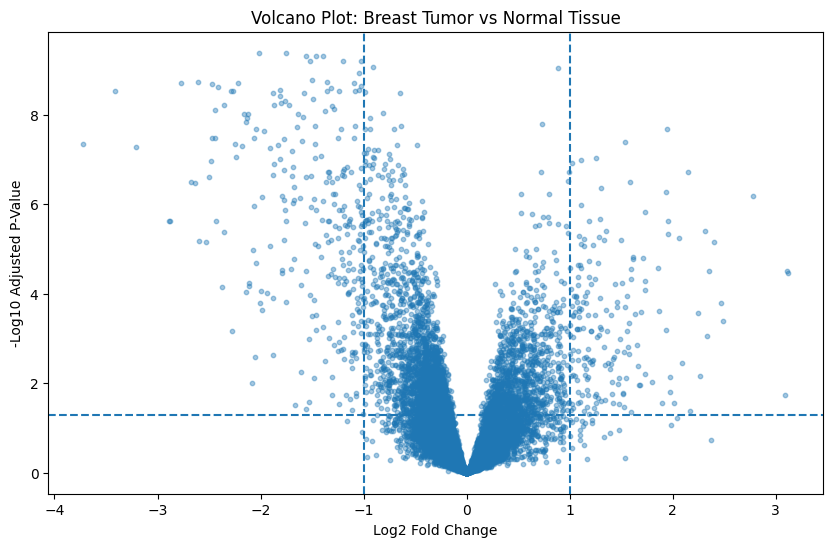

In [19]:
geo_data["Negative_Log10_FDR"] = -np.log10(
    geo_data["Adjusted_P_Value"].clip(lower=1e-300)
)

plt.figure(figsize=(10, 6))

plt.scatter(
    geo_data["Log2_Fold_Change"],
    geo_data["Negative_Log10_FDR"],
    alpha=0.4,
    s=10
)

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-Value")
plt.title("Volcano Plot: Breast Tumor vs Normal Tissue")

plt.show()

In [20]:
geo_data["Expression_Status"] = "Not Significant"

geo_data.loc[
    (geo_data["Adjusted_P_Value"] < 0.05) &
    (geo_data["Log2_Fold_Change"] >= 1),
    "Expression_Status"
] = "Higher in Tumor"

geo_data.loc[
    (geo_data["Adjusted_P_Value"] < 0.05) &
    (geo_data["Log2_Fold_Change"] <= -1),
    "Expression_Status"
] = "Lower in Tumor"

print(geo_data["Expression_Status"].value_counts())

Expression_Status
Not Significant    21840
Lower in Tumor       262
Higher in Tumor      181
Name: count, dtype: int64


### Highlighting Significant Expression Changes

Significantly differentially expressed probe sets were highlighted according to the direction of expression change. Probe sets with increased expression in tumor tissue were distinguished from those with decreased expression, while probe sets that did not meet both significance thresholds were displayed separately.

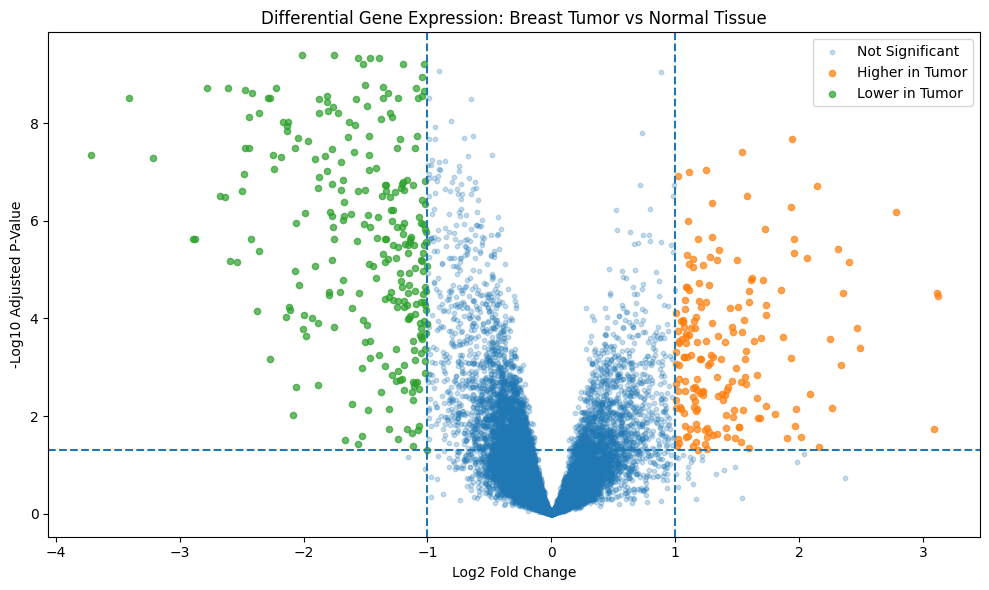

In [21]:
plt.figure(figsize=(10, 6))

not_sig = geo_data[
    geo_data["Expression_Status"] == "Not Significant"
]

higher = geo_data[
    geo_data["Expression_Status"] == "Higher in Tumor"
]

lower = geo_data[
    geo_data["Expression_Status"] == "Lower in Tumor"
]

plt.scatter(
    not_sig["Log2_Fold_Change"],
    not_sig["Negative_Log10_FDR"],
    alpha=0.25,
    s=10,
    label="Not Significant"
)

plt.scatter(
    higher["Log2_Fold_Change"],
    higher["Negative_Log10_FDR"],
    alpha=0.7,
    s=20,
    label="Higher in Tumor"
)

plt.scatter(
    lower["Log2_Fold_Change"],
    lower["Negative_Log10_FDR"],
    alpha=0.7,
    s=20,
    label="Lower in Tumor"
)

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-Value")
plt.title("Differential Gene Expression: Breast Tumor vs Normal Tissue")

plt.legend()
plt.tight_layout()
plt.show()

## 13. Top Differentially Expressed Genes

Significant probe sets were mapped to gene symbols using the GPL96 platform annotation. Genes showing some of the largest expression differences between breast tumor and normal tissue were then examined.

In [22]:
top_higher_genes = significant_with_genes[
    significant_with_genes["Log2_Fold_Change"] >= 1
].sort_values(
    "Log2_Fold_Change",
    ascending=False
)

top_lower_genes = significant_with_genes[
    significant_with_genes["Log2_Fold_Change"] <= -1
].sort_values(
    "Log2_Fold_Change",
    ascending=True
)

print("Top 10 higher in tumor:")
display(
    top_higher_genes[
        ["Gene Symbol", "Log2_Fold_Change", "Adjusted_P_Value"]
    ].head(10)
)

print("\nTop 10 lower in tumor:")
display(
    top_lower_genes[
        ["Gene Symbol", "Log2_Fold_Change", "Adjusted_P_Value"]
    ].head(10)
)

Top 10 higher in tumor:


,Gene Symbol,Log2_Fold_Change,Adjusted_P_Value
ID_REF,,,
201650_at,KRT19,3.118174,3.489261e-05
209016_s_at,KRT7,3.112585,3.076304e-05
37892_at,COL11A1,3.085490,1.868585e-02
266_s_at,CD24,2.781450,6.620560e-07
208650_s_at,CD24,2.490458,4.075543e-04
213693_s_at,MUC1,2.465403,1.595182e-04
212281_s_at,TMEM97,2.401528,6.935820e-06
201596_x_at,KRT18,2.355316,3.050640e-05
204825_at,MELK,2.335196,8.945851e-04



Top 10 lower in tumor:


,Gene Symbol,Log2_Fold_Change,Adjusted_P_Value
ID_REF,,,
222317_at,PDE3B,-3.719666,4.429541e-08
219140_s_at,RBP4,-3.409901,2.989066e-09
205478_at,PPP1R1A,-3.213164,5.120538e-08
204997_at,GPD1,-2.890026,2.369449e-06
206243_at,TIMP4,-2.876761,2.338976e-06
207092_at,LEP,-2.776224,1.946770e-09
213071_at,DPT,-2.676463,3.103954e-07
211745_x_at,HBA1 /// HBA2,-2.636815,3.318157e-07
205382_s_at,CFD,-2.606642,1.873043e-09


### Gene-Level Result Cleaning

Because microarray platforms may contain multiple probe sets representing the same gene, gene symbols were cleaned and duplicate gene entries were removed before visualization. This prevents the same gene from appearing multiple times among the top results.

In [23]:
higher_clean = top_higher_genes.dropna(
    subset=["Gene Symbol"]
).copy()

lower_clean = top_lower_genes.dropna(
    subset=["Gene Symbol"]
).copy()

# Keep the first gene symbol when multiple symbols are listed
higher_clean["Gene Symbol"] = (
    higher_clean["Gene Symbol"]
    .str.split(" /// ")
    .str[0]
)

lower_clean["Gene Symbol"] = (
    lower_clean["Gene Symbol"]
    .str.split(" /// ")
    .str[0]
)

# Remove duplicate gene symbols
higher_clean = higher_clean.drop_duplicates(
    subset=["Gene Symbol"]
)

lower_clean = lower_clean.drop_duplicates(
    subset=["Gene Symbol"]
)

print("Top genes higher in tumor:")
display(
    higher_clean[
        ["Gene Symbol", "Log2_Fold_Change", "Adjusted_P_Value"]
    ].head(10)
)

print("\nTop genes lower in tumor:")
display(
    lower_clean[
        ["Gene Symbol", "Log2_Fold_Change", "Adjusted_P_Value"]
    ].head(10)
)

Top genes higher in tumor:


,Gene Symbol,Log2_Fold_Change,Adjusted_P_Value
ID_REF,,,
201650_at,KRT19,3.118174,3.489261e-05
209016_s_at,KRT7,3.112585,3.076304e-05
37892_at,COL11A1,3.085490,1.868585e-02
266_s_at,CD24,2.781450,6.620560e-07
213693_s_at,MUC1,2.465403,1.595182e-04
212281_s_at,TMEM97,2.401528,6.935820e-06
201596_x_at,KRT18,2.355316,3.050640e-05
204825_at,MELK,2.335196,8.945851e-04
209602_s_at,GATA3,2.312736,3.857666e-06



Top genes lower in tumor:


,Gene Symbol,Log2_Fold_Change,Adjusted_P_Value
ID_REF,,,
222317_at,PDE3B,-3.719666,4.429541e-08
219140_s_at,RBP4,-3.409901,2.989066e-09
205478_at,PPP1R1A,-3.213164,5.120538e-08
204997_at,GPD1,-2.890026,2.369449e-06
206243_at,TIMP4,-2.876761,2.338976e-06
207092_at,LEP,-2.776224,1.946770e-09
213071_at,DPT,-2.676463,3.103954e-07
211745_x_at,HBA1,-2.636815,3.318157e-07
205382_s_at,CFD,-2.606642,1.873043e-09


## 14. Visualization of Top Differentially Expressed Genes

The genes with the largest positive and negative log2 fold changes were visualized to highlight major expression differences between breast tumor and normal tissue.

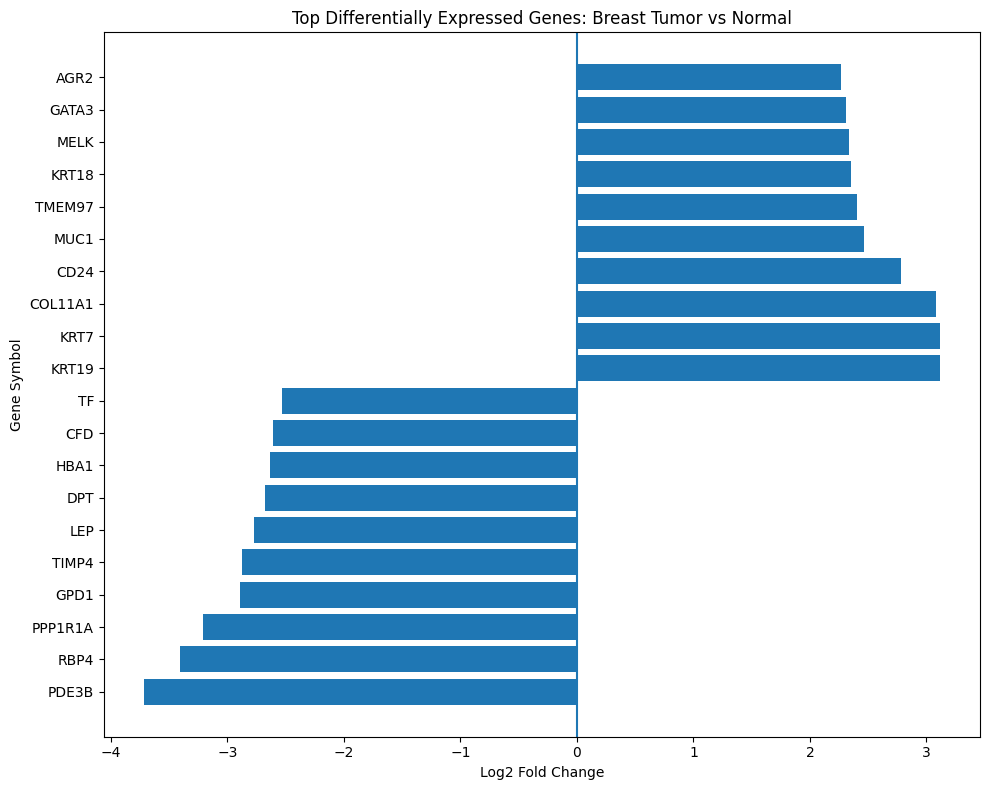

In [24]:
top_higher_10 = higher_clean.head(10)
top_lower_10 = lower_clean.head(10)

top_genes = pd.concat([
    top_lower_10,
    top_higher_10
])

plt.figure(figsize=(10, 8))

plt.barh(
    top_genes["Gene Symbol"],
    top_genes["Log2_Fold_Change"]
)

plt.axvline(x=0)

plt.xlabel("Log2 Fold Change")
plt.ylabel("Gene Symbol")
plt.title("Top Differentially Expressed Genes: Breast Tumor vs Normal")

plt.tight_layout()
plt.show()

## 15. Results and Conclusion

The analysis compared gene expression profiles from 43 breast tumor samples and 43 paired normal breast tissue samples from the GSE15852 dataset.

A paired statistical analysis was performed to account for the matched tumor-normal study design. P-values were corrected for multiple testing using the Benjamini-Hochberg false discovery rate (FDR) method.

Using an adjusted p-value threshold of < 0.05 and an absolute log2 fold-change threshold of ≥ 1, 443 probe sets were identified as significantly differentially expressed.

Of these:

- 181 probe sets showed higher expression in tumor tissue.
- 262 probe sets showed lower expression in tumor tissue.

GPL96 platform annotation was used to associate significant Affymetrix probe sets with gene symbols. Volcano and bar-plot visualizations were used to summarize the magnitude and statistical significance of expression differences.

Overall, the analysis demonstrates substantial gene-expression differences between breast tumor and paired normal breast tissue and provides candidate genes for further biological investigation.

## 16. Limitations

This analysis is an exploratory educational bioinformatics project. Differential expression was evaluated at the Affymetrix probe-set level, and some probe sets may map to multiple genes or multiple probe sets may represent the same gene.

Gene-expression differences represent associations with tumor status and do not establish that a gene causes or prevents breast cancer.

Additional validation, alternative statistical methods, functional enrichment analysis, and independent datasets would be needed before drawing stronger biological or clinical conclusions.

In [25]:
final_results = significant_with_genes[
    [
        "Gene Symbol",
        "Gene Title",
        "Normal_Mean",
        "Tumor_Mean",
        "Log2_Fold_Change",
        "P_Value",
        "Adjusted_P_Value"
    ]
].copy()

final_results = final_results.sort_values(
    "Adjusted_P_Value"
)

final_results.to_csv(
    "GSE15852_significant_results.csv"
)

print("Results exported successfully!")
print("Number of significant probe sets:", len(final_results))

final_results.head(10)

Results exported successfully!
Number of significant probe sets: 443


,Gene Symbol,Gene Title,Normal_Mean,Tumor_Mean,Log2_Fold_Change,P_Value,Adjusted_P_Value
ID_REF,,,,,,,
207175_at,ADIPOQ,"adiponectin, C1Q and collagen domain containing",5855.035977,1737.780628,-1.751848,3.660197e-14,4.078009e-10
209699_x_at,AKR1C2 /// LOC101930400,"aldo-keto reductase family 1, member C2 /// al...",5462.430395,1354.536456,-2.010943,1.945002e-14,4.078009e-10
216594_x_at,AKR1C1,"aldo-keto reductase family 1, member C1",5135.710256,1957.483419,-1.391108,9.659205e-14,4.739027e-10
213524_s_at,G0S2,G0/G1 switch 2,4663.866047,1692.587000,-1.461754,6.424882e-14,4.739027e-10
204151_x_at,AKR1C1,"aldo-keto reductase family 1, member C1",6778.620395,2292.681535,-1.563539,1.063373e-13,4.739027e-10
203980_at,FABP4,"fatty acid binding protein 4, adipocyte",7957.622558,2778.560209,-1.517662,1.851433e-13,6.281043e-10
213348_at,CDKN1C,"cyclin-dependent kinase inhibitor 1C (p57, Kip2)",2656.579814,1301.667814,-1.028644,2.031590e-13,6.281043e-10
221748_s_at,TNS1,tensin 1,5609.990698,2440.967140,-1.200212,2.255008e-13,6.281043e-10
209763_at,CHRDL1,chordin-like 1,3277.130512,1592.701605,-1.040492,5.625113e-13,1.139494e-09
